In [1]:
import numpy as np
import tensorflow as tf
import keras
import csv
import matplotlib.pyplot as plt
import pandas as pd

from feos.eos import EquationOfState, State, Contributions
from feos.pets import PetsParameters
import si_units as si

import sys
sys.path.append("..")
import minimise

# Enable or disable Tensor Float 32 Execution
tf.config.experimental.enable_tensor_float_32_execution(False)

2026-02-28 12:54:05.572508: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 12:54:05.671956: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772283245.714213   38217 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772283245.728070   38217 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-28 12:54:05.822672: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
def write_profile(filename, centers, densities_A, densities_B):
    """
    Write the density profiles to a file.

    Parameters:
    - filename (str): Output file name.
    - centers (np.ndarray): Bin centers.
    - densities (np.ndarray): Density values.
    """
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile, delimiter=' ')
        writer.writerow(["xbins", "rho_A", "rho_B"])
        for center, density_a, density_b in zip(centers, densities_A, densities_B):
            writer.writerow([f"{center:.4f}", f"{density_a:.20f}", f"{density_b:.20f}"])


def LJ_wall(position, low, high, epsilon=2, sigma=1):
    r_low = position - low
    r_high = high - position
    
    energy_low = 4 * epsilon * ((sigma / r_low)**12 - (sigma / r_low)**6)
    energy_high = 4 * epsilon * ((sigma / r_high)**12 - (sigma / r_high)**6)
    
    return np.where((position >= high) | (position <= low), 1e30, energy_low + energy_high)


def hard_wall(position, low, high):
    V = np.zeros_like(position)
    V[position <= low] = 1e30
    V[position >= high] = 1e30
    return V


def get_slit_profile_lr(model_path, output_file, temp,
                        mu_A, mu_B, rho_b_A, rho_b_B,
                        eps_AA, eps_BB, int_param, sigma_AA=1.0, sigma_BB=1.0,
                        L = 8, dx = 0.005, low_wall = 1.5, high_wall = 8.5, eps_wall=2.0,
                        initial_guess_A = 0.5, initial_guess_B = 0.5, plot=True, hs = False, mf = False
                        ):

    """
    Determine the self-consistent density profiles with neural DFT for a confined fluid.

    Parameters:
    - model_path (str): Path to the Keras model.
    - output_file (str): Filename to save results.
    - temp (float): Temperature
    - mu (float): Chemical potential in units of kbT
    - rho_b (float): Bulk density to use to calculate mu_R
    - int_param (float): Used to calculate eps_AB = (1-int_param)*sqrt(eps_AA*eps_BB)
    """

    model = keras.models.load_model(model_path)

    zbins = np.linspace(dx/2, L-dx/2, num = int(L/dx))
    Vext = LJ_wall(zbins, low_wall, high_wall, eps_wall)
    if eps_wall == 0:
        Vext = hard_wall(zbins, low_wall, high_wall)
    T = temp*np.ones_like(zbins)

    if hs and mf:
        zs, rho_a, rho_b = minimise.minimise_LR_twotype_HS_mf(model, zbins, T,
                                           -Vext, -Vext,
                                           eps_AA = eps_AA, eps_BB = eps_BB, interaction_parameter=int_param,
                                           sigma_AA=sigma_AA, sigma_BB=sigma_BB,
                                           mu_A=mu_A, mu_B = mu_B,
                                           rho_bulk_A=rho_b_A, rho_bulk_B=rho_b_B,
                                           initial_guess_A=initial_guess_A, initial_guess_B=initial_guess_B,
                                           input_bins=513, plot=plot, alpha_initial=1e-7,
                                           tolerance=5e-5, maxiter=20000)
        
    elif hs and not mf:
        zs, rho_a, rho_b = minimise.minimise_LR_twotype_HS(model, zbins, T,
                                           -Vext, -Vext,
                                           eps_AA = eps_AA, eps_BB = eps_BB, interaction_parameter=int_param,
                                           sigma_AA=sigma_AA, sigma_BB=sigma_BB,
                                           mu_A=mu_A, mu_B = mu_B,
                                           rho_bulk_A=rho_b_A, rho_bulk_B=rho_b_B,
                                           initial_guess_A=initial_guess_A, initial_guess_B=initial_guess_B,
                                           input_bins=513, plot=plot, alpha_initial=1e-7,
                                           tolerance=5e-5, maxiter=20000)
        
    elif mf and not hs:
        zs, rho_a, rho_b = minimise.minimise_LR_twotype_MF(model, zbins, T,
                                           -Vext, -Vext,
                                           eps_AA = eps_AA, eps_BB = eps_BB, interaction_parameter=int_param,
                                           sigma_AA=sigma_AA, sigma_BB=sigma_BB,
                                           mu_A=mu_A, mu_B = mu_B,
                                           rho_bulk_A=rho_b_A, rho_bulk_B=rho_b_B,
                                           initial_guess_A=initial_guess_A, initial_guess_B=initial_guess_B,
                                           input_bins=1201, plot=plot, alpha_initial=1e-7,
                                           tolerance=5e-6, maxiter=20000)
        
    else:
        zs, rho_a, rho_b = minimise.minimise_LR_twotype_onemodel(model, zbins, T,
                                           -Vext, -Vext,
                                           eps_AA = eps_AA, eps_BB = eps_BB, interaction_parameter=int_param,
                                           sigma_AA=sigma_AA, sigma_BB=sigma_BB,
                                           mu_A=mu_A, mu_B = mu_B,
                                           rho_bulk_A=rho_b_A, rho_bulk_B=rho_b_B,
                                           initial_guess_A=initial_guess_A, initial_guess_B=initial_guess_B,
                                           input_bins=1201, plot=plot, alpha_initial=1e-7,
                                           tolerance=5e-6, maxiter=20000)
    
    if zs is not None:
        write_profile(output_file, zs, rho_a, rho_b)
        return zs, rho_a, rho_b

In [3]:
eps_AA = 1.0
eps_BB = 0.9
int_param = 0.15
sigma = np.ones((2))

parameters = PetsParameters.from_lists(sigma = sigma,
                                       epsilon_k = np.array([eps_AA, eps_BB]),
                                       k_ij = np.array([[0, int_param], [int_param, 0]])
                                       )

pets_azeo = EquationOfState.pets(parameters)

In [4]:
x = 0.78
p = 0.02
T = 0.77

s = State(
    eos=pets_azeo,
    temperature=T*si.KELVIN,
    molefracs = np.array([1-x, x]),
    pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
    )

rho_tot = s.density * si.NAV * si.ANGSTROM**3
rho_mixture = rho_tot*np.array([1-x, x])
betamu = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture)

L = 11 # Slit length including wall width
width = 1.5 # Slit wall width
eps_w = 2.5

Iteration 0: delta = 0.9999977508217354
Iteration 1000: delta = 0.6262844024293224
Iteration 2000: delta = 0.7149004516306776
Iteration 3000: delta = 0.3380495924584521
Iteration 4000: delta = 0.08396428477325646
Iteration 5000: delta = 0.013249095813321343
Iteration 6000: delta = 0.0011231214768585573
Converged after 6774 iterations (delta = 7.810131392060882e-06)
Iteration 0: delta = 0.9999969887701499
Iteration 1000: delta = 0.6240600626627862
Iteration 2000: delta = 1.0330915224855823
Iteration 3000: delta = 0.4044315786249346
Iteration 4000: delta = 0.10599876465169955
Iteration 5000: delta = 0.019963379845637563
Iteration 6000: delta = 0.002255871431194212
Converged after 6617 iterations (delta = 9.633520796015205e-05)
Iteration 0: delta = 0.9999969900773126
Iteration 1000: delta = 0.6241114773309749
Iteration 2000: delta = 1.0378344858544506
Iteration 3000: delta = 0.4048156678556236
Iteration 4000: delta = 0.1064529705423809
Iteration 5000: delta = 0.020145594675252898
Iteratio

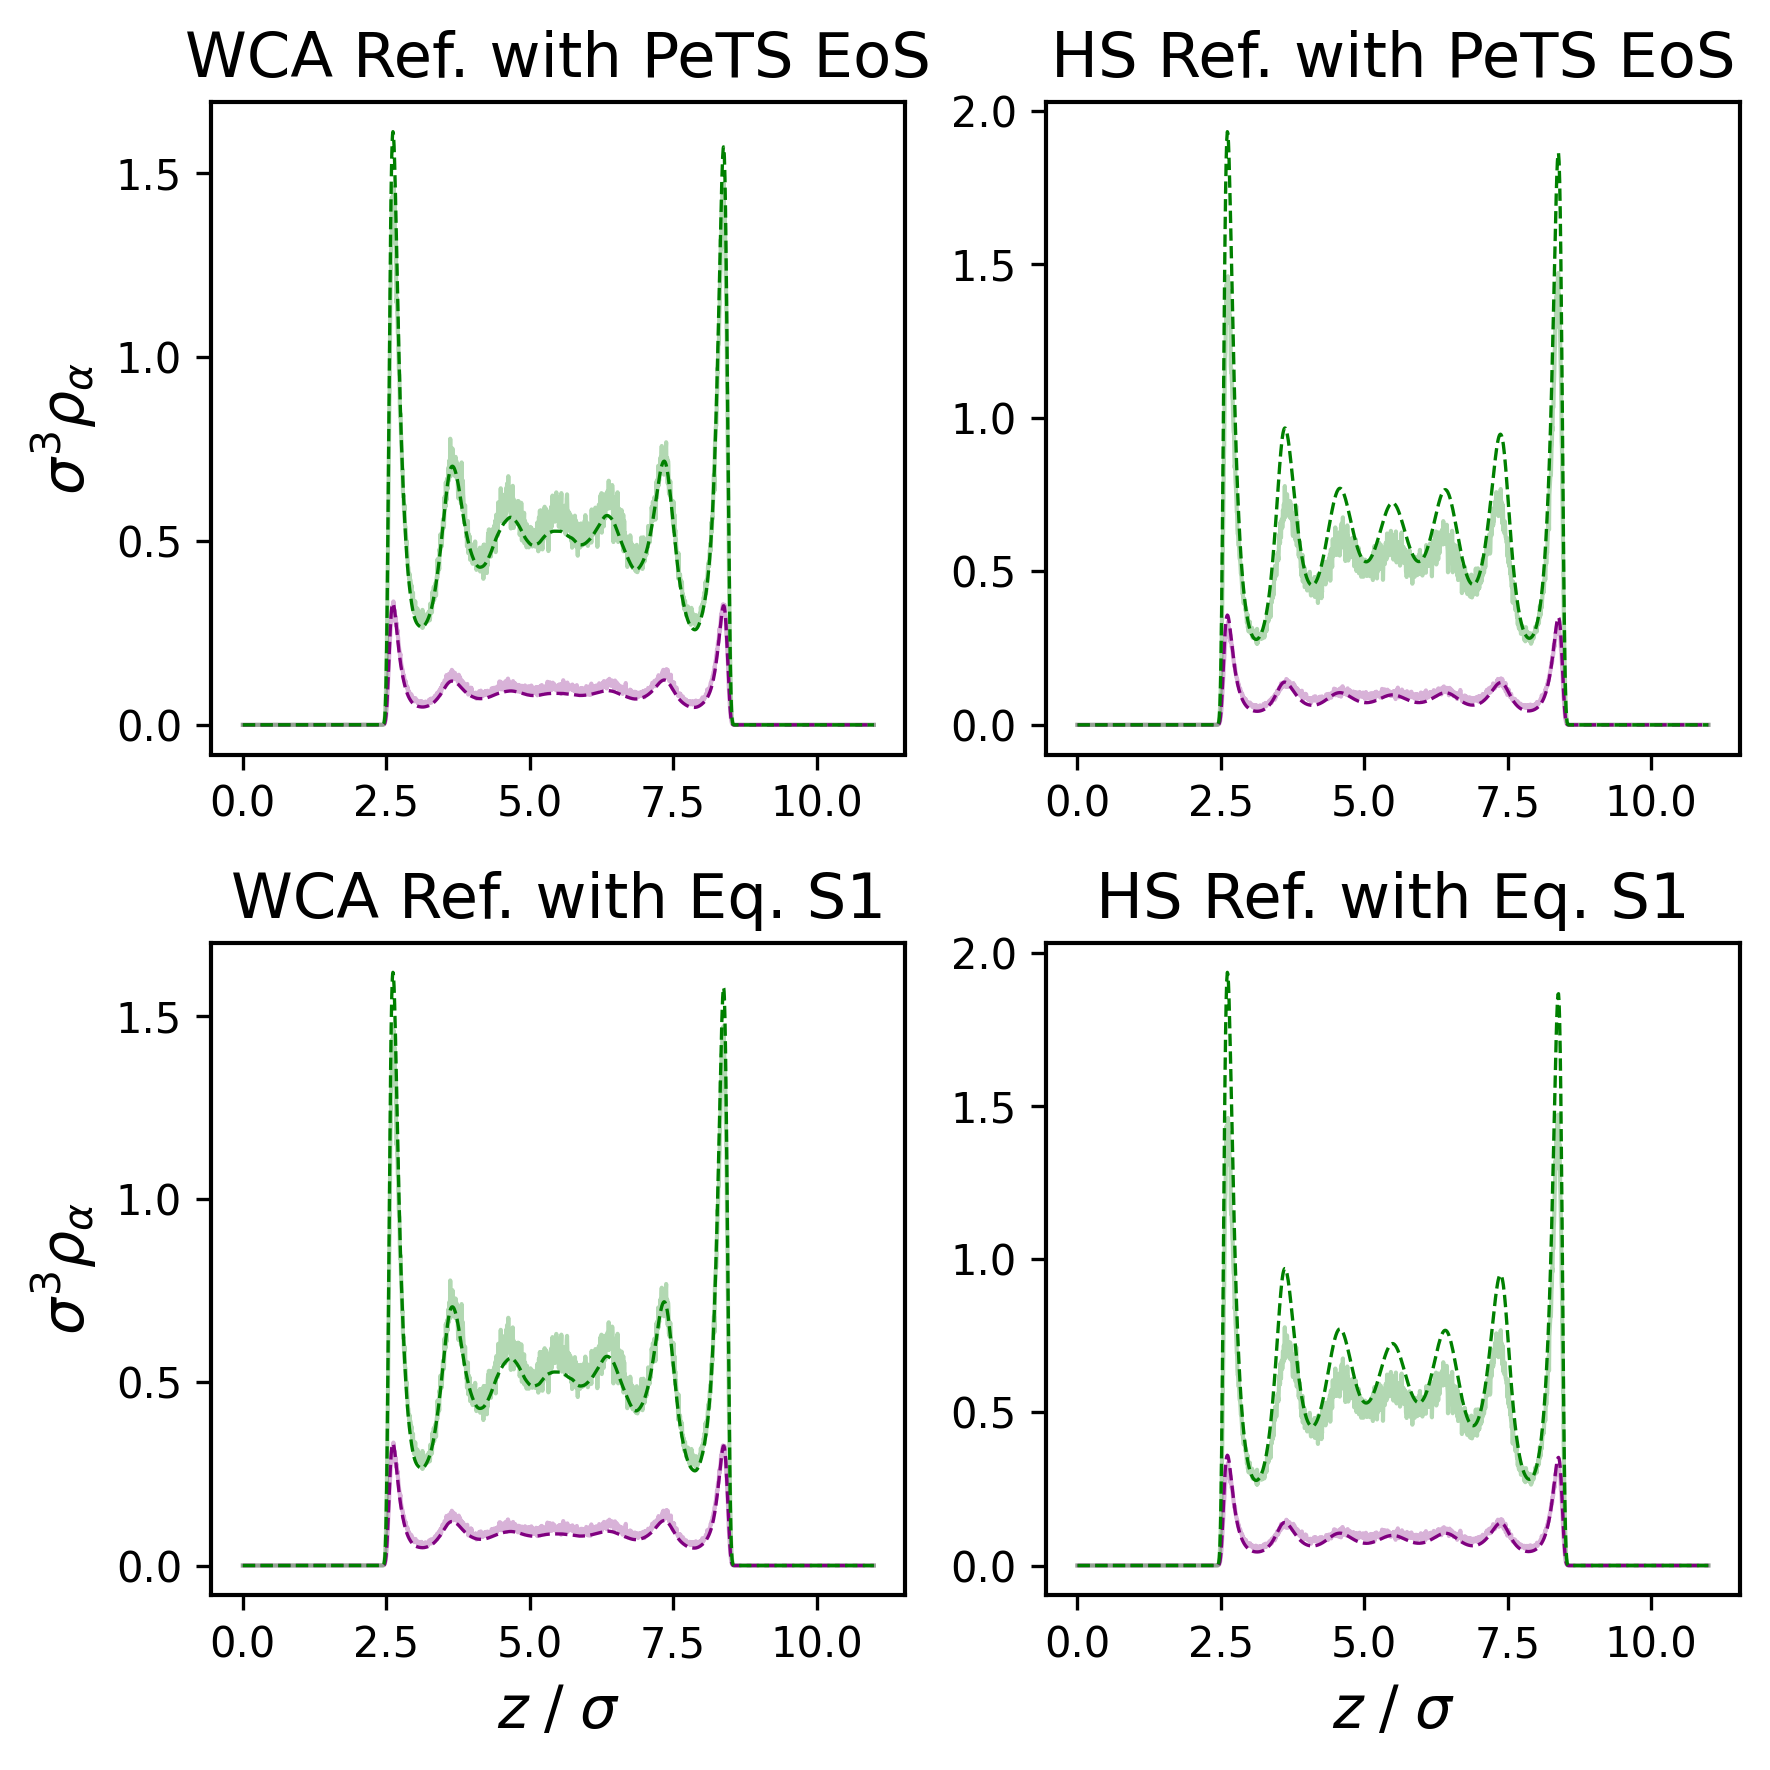

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6, 6))
ax = axes.flatten()

data_A = f"../../data/simulation/mixtures/T0.77_x0.78_p0.02/eps_{eps_w:.1f}/H_profiles.out"
data_B = f"../../data/simulation/mixtures/T0.77_x0.78_p0.02/eps_{eps_w:.1f}/O_profiles.out"
sim_a = pd.read_csv(data_A, sep=" ")
sim_b = pd.read_csv(data_B, sep=" ")

xbins = sim_b["xbins"].to_numpy()

for axs in ax:  
    axs.plot(xbins, sim_a["rho"].to_numpy(), lw = 1, color="purple", alpha=0.3)
    axs.plot(xbins, sim_b["rho"].to_numpy(), lw = 1, color="green", alpha=0.3)

model_path = "../../models/WCA.keras"
output_file = f"../../data/results/density_profiles/mixtures/lr_pred_slit_T{T:.2f}_p{p:.2f}_x{x:.2f}_eps{eps_w:.1f}.out"

zs, rho_a, rho_b = get_slit_profile_lr(model_path, output_file, T,
                    mu_A = betamu[0], mu_B = betamu[1],
                    rho_b_A = rho_mixture[0], rho_b_B = rho_mixture[1],
                    eps_AA = eps_AA, eps_BB = eps_BB, int_param = int_param,
                    L = L, low_wall = width, high_wall = L - width, eps_wall = eps_w,
                    plot=False,
                    initial_guess_A = 1, initial_guess_B = 1, 
                    )

ax[0].plot(zs, rho_a, color="purple", lw = 0.8, linestyle="dashed")
ax[0].plot(zs, rho_b, color="green", lw = 0.8, linestyle="dashed")

ax[0].set_title("WCA Ref. with PeTS EoS")

model_path = "../../models/HS.keras"
output_file = f"../../data/results/density_profiles/mixtures/hs_pred_slit_T{T:.2f}_p{p:.2f}_x{x:.2f}_eps{eps_w:.1f}.out"

zs, rho_a, rho_b = get_slit_profile_lr(model_path, output_file, T,
                    mu_A = betamu[0], mu_B = betamu[1],
                    rho_b_A = rho_mixture[0], rho_b_B = rho_mixture[1],
                    eps_AA = eps_AA, eps_BB = eps_BB, int_param = int_param,
                    L = L, low_wall = width, high_wall = L - width, eps_wall = eps_w,
                    dx = 0.01, hs = True,  plot=False,
                    initial_guess_A = 1, initial_guess_B = 1,
                    )

ax[1].plot(zs, rho_a, color="purple", lw = 0.8, linestyle="dashed")
ax[1].plot(zs, rho_b, color="green", lw = 0.8, linestyle="dashed")

ax[1].set_title("HS Ref. with PeTS EoS")

output_file = f"../../data/results/density_profiles/mixtures/hs_mf_pred_slit_T{T:.2f}_p{p:.2f}_x{x:.2f}_eps{eps_w:.1f}.out"

zs, rho_a, rho_b = get_slit_profile_lr(model_path, output_file, T,
                    mu_A = betamu[0], mu_B = betamu[1],
                    rho_b_A = rho_mixture[0], rho_b_B = rho_mixture[1],
                    eps_AA = eps_AA, eps_BB = eps_BB, int_param = int_param,
                    L = L, low_wall = width, high_wall = L - width, eps_wall = eps_w,
                    dx = 0.01, hs = True,  mf = True, plot=False,
                    initial_guess_A = 1, initial_guess_B = 1,
                    )

ax[3].plot(zs, rho_a, color="purple", lw = 0.8, linestyle="dashed")
ax[3].plot(zs, rho_b, color="green", lw = 0.8, linestyle="dashed")

ax[3].set_title("HS Ref. with Eq. S1")

model_path = "../../models/WCA.keras"
output_file = f"../../data/results/density_profiles/mixtures/mf_pred_slit_T{T:.2f}_p{p:.2f}_x{x:.2f}_eps{eps_w:.1f}.out"

zs, rho_a, rho_b = get_slit_profile_lr(model_path, output_file, T,
                    mu_A = betamu[0], mu_B = betamu[1],
                    rho_b_A = rho_mixture[0], rho_b_B = rho_mixture[1],
                    eps_AA = eps_AA, eps_BB = eps_BB, int_param = int_param,
                    L = L, low_wall = width, high_wall = L - width, eps_wall = eps_w,
                    mf = True, plot = False,
                    initial_guess_A = 1, initial_guess_B = 1,
                    )

ax[2].plot(zs, rho_a, color="purple", lw = 0.8, linestyle="dashed")
ax[2].plot(zs, rho_b, color="green", lw = 0.8, linestyle="dashed")

ax[2].set_title("WCA Ref. with Eq. S1")

ax[0].set_ylabel(r"$ \sigma^3 \rho_{\alpha}$")
ax[2].set_ylabel(r"$ \sigma^3 \rho_{\alpha}$")
ax[2].set_xlabel(r"$ z \; / \; \sigma$")
ax[3].set_xlabel(r"$ z \; / \; \sigma$")

plt.tight_layout()